# Getting started with dLux

This tutorial builds a complete differentiable imaging model and fits it to simulated data. The model combines an asymmetric pupil, Zernike optical-path difference (OPD), focal-plane propagation, and a polychromatic stellar source.

We recover the source flux, position, effective temperature, and optical aberrations, illustrating the central dLux workflow before later tutorials examine each component in detail.

In [1]:
import jax.numpy as np
import jax.random as jr
import equinox as eqx
import optax
import zodiax as zdx
from tqdm.notebook import tqdm

import dLux as dl

In [2]:
## COLLAPSE: Plotting setup
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import CenteredNorm, PowerNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable

%matplotlib inline
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "font.family": "serif",
        "image.cmap": "inferno",
        "image.origin": "lower",
    }
)

# Colormaps with consistent handling outside the physical support
bad = (0.0, 0.0, 0.0, 0.5)
cmaps = {
    "intensity": mpl.colormaps["inferno"].with_extremes(bad=bad),
    "opd": mpl.colormaps["RdBu"].with_extremes(bad=bad),
    "residual": mpl.colormaps["seismic"].with_extremes(bad=bad),
    "phase": mpl.colormaps["twilight_shifted"].with_extremes(bad=bad),
}

# Attach a colour bar without resizing or separating the image axes
def colorbar(image, label, size="5%", pad=0.05):
    ax = image.axes
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size=size, pad=pad)
    return ax.figure.colorbar(image, cax=cax, label=label)

In [3]:
# Apply every recognised parameter to a collection of Zodiax objects
def update(params, *objects):
    unused = set(params)
    updated = []

    for obj in objects:
        values = {}
        for path, value in params.items():
            try:
                obj.get(path, to_array=False)
            except AttributeError:
                continue
            values[path] = value
            unused.discard(path)
        updated.append(obj.set(**values))

    if unused:
        print(f"Unused parameters: {sorted(unused)}")
    return tuple(updated)

## Build the optical model

A `GridSpec` defines the sampling and physical units of each optical plane. Here a 256-pixel grid spans the 1.3 metre pupil, while a 64-pixel grid samples the focal plane at 50 milliarcseconds per pixel.

`EuclidLike` provides an approximate asymmetric pupil that breaks a sign degeneracy in focal-plane phase retrieval. We widen its support arms so their diffraction signature remains visible in this compact example.

The builder returns an `Optic` containing the sampled transmission and a support-clipped Zernike OPD basis. A `Fraunhofer` layer propagates the field onto the focal grid. We first propagate a monochromatic wavefront directly, then inspect the transmission, injected OPD, and resulting focal-plane intensity.

In [4]:
# Define the pupil and focal-plane sampling
pupil_grid = dl.GridSpec(n=256, diam=1.3, unit="m")
focal_grid = dl.GridSpec(n=64, d=50, unit="mas")

# Build a Euclid-like aperture with wider spiders and zernikes
pupil_def = dl.EuclidLike(
    spider_width=0.05,
    opd=dl.ZernikeDef(
        orders=[2, 3],
        norm=dl.Norm("rms", 50e-9),
    ),
)

# Assemble the pupil and focal propagation into an optical system
optics = dl.OpticalSystem(
    grid=pupil_grid,  # Define the Pupil grid
    layers=[
        ("pupil", pupil_def(pupil_grid, key=jr.key(0))),  # Construct the pupil layer
        ("focus", dl.Fraunhofer(focal_grid)),  # Propagate to the focal grid
    ],
)

# Propagate a monochromatic on-axis point source
psf = optics.propagate(1e-6)

# Examine the system
print(optics)

OpticalSystem(
  layers={
    'pupil':
    Optic(
      opd=Basis(coeffs=f32[7], shape=(7,), basis=f32[7,256,256]),
      phase=None,
      transmission=f32[256,256],
      normalise=True
    ),
    'focus':
    Fraunhofer(
      grid=GridSpec(n=(64, 64), d=f32[2], c=None, unit='mas'),
      focal_length=None,
      inverse=False,
      method='mft'
    )
  },
  grid=GridSpec(n=(256, 256), d=f32[2], c=None, unit='m')
)


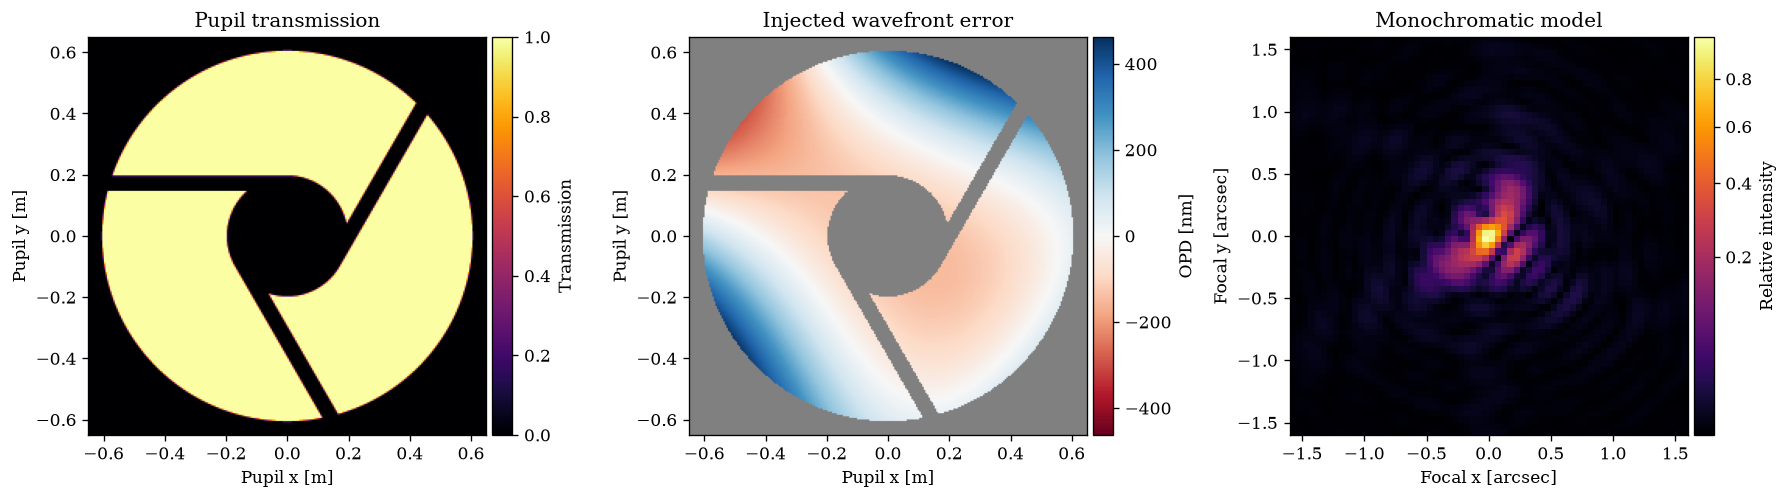

In [5]:
## COLLAPSE: Plotting code
# Resolve the plotted quantities and their physical extents
opd = optics.opd.evaluate()
transmission = optics.transmission
opd = np.where(transmission > 0.5, 1e9 * opd, np.nan)
intensity = psf / psf.max()

pupil_extent = pupil_grid.extent(ndim=2, unit="m")
focal_extent = focal_grid.extent(ndim=2, unit="arcsec")

# Plot the physical pupil and focal-plane model
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
image = axes[0].imshow(transmission, cmaps["intensity"], extent=pupil_extent)
axes[0].set(title="Pupil transmission", xlabel="Pupil x [m]", ylabel="Pupil y [m]")
colorbar(image, "Transmission")

image = axes[1].imshow(opd, cmaps["opd"], extent=pupil_extent, norm=CenteredNorm())
axes[1].set(title="Injected wavefront error", xlabel="Pupil x [m]", ylabel="Pupil y [m]")
colorbar(image, "OPD [nm]")

image = axes[2].imshow(intensity, cmaps["intensity"], extent=focal_extent, norm=PowerNorm(0.5))
axes[2].set(title="Monochromatic model", xlabel="Focal x [arcsec]", ylabel="Focal y [arcsec]")
colorbar(image, "Relative intensity")

fig.tight_layout()
plt.show()

## Simulate an exposure

We now replace the direct propagation with a physical source model. Its wavelength samples cover a finite band, while its photon flux, angular position, and effective temperature remain explicit model parameters for the fit. The resulting `Image` simulates repeated photon and read-noise realisations and stores the variance of their mean.

In [6]:
# Define a polychromatic stellar source in convenient physical units
source = dl.Source(
    flux=5.,
    position=np.array([35.0, -20.0]),
    wavelengths=np.linspace(0.8, 1.2, 9),
    weights=dl.Blackbody(temperature=5800.0),
    units={"wavelengths": "um", "position": "mas", "flux": "log"},
)

# Generate the expected detector image and simulated exposure
PSF = optics.model(source)
image = dl.Image(PSF, read_noise=10.)
exposure = image.simulate(jr.key(1), n_frames=64)

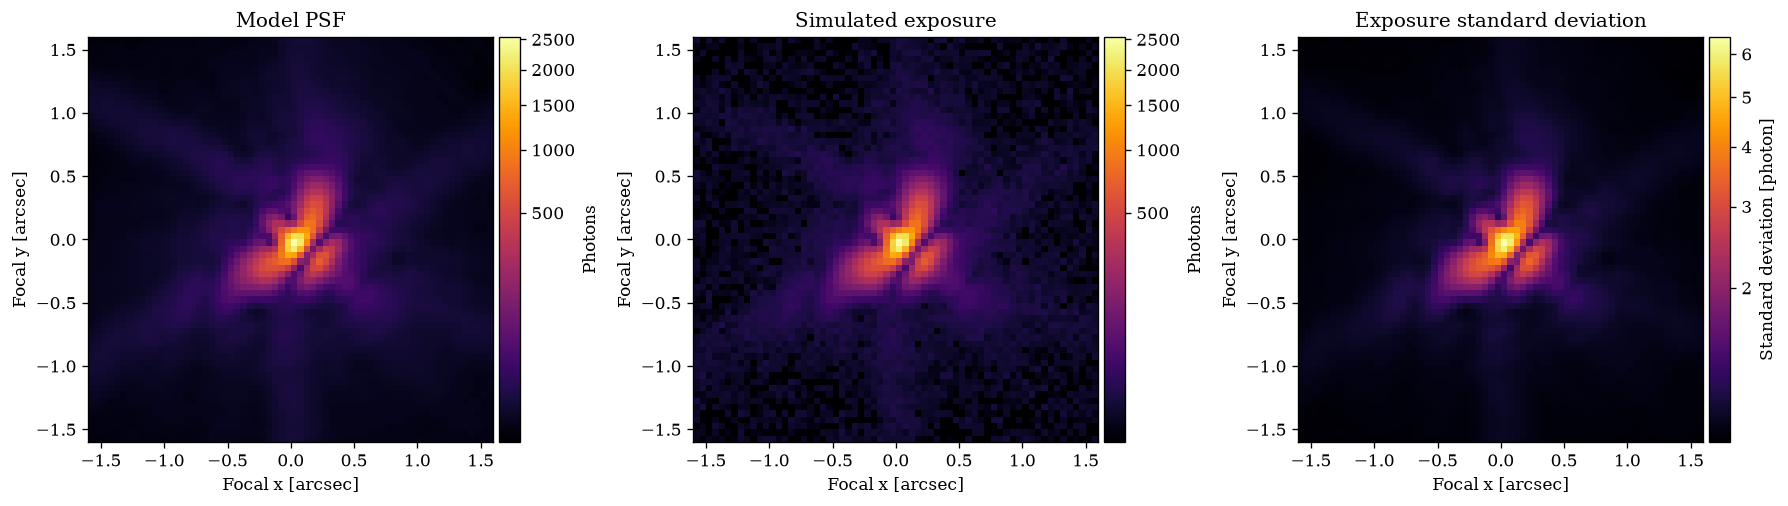

In [7]:
## COLLAPSE: Plotting code
# Use one raw photon scale for the model and simulated exposure
vmax = np.maximum(PSF.data.max(), exposure.data.max())
norm = PowerNorm(0.35)

# Plot the model, exposure, and propagated standard deviation
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
im = axes[0].imshow(PSF.data, cmaps["intensity"], extent=focal_extent, norm=norm)
axes[0].set(title="Model PSF", xlabel="Focal x [arcsec]", ylabel="Focal y [arcsec]")
colorbar(im, "Photons")

im = axes[1].imshow(exposure.data, cmaps["intensity"], extent=focal_extent, norm=norm)
axes[1].set(title="Simulated exposure", xlabel="Focal x [arcsec]", ylabel="Focal y [arcsec]")
colorbar(im, "Photons")

im = axes[2].imshow(exposure.error, cmaps["intensity"], extent=focal_extent, norm=PowerNorm(0.5))
axes[2].set(title="Exposure standard deviation", xlabel="Focal x [arcsec]", ylabel="Focal y [arcsec]")
colorbar(im, "Standard deviation [photon]")

fig.tight_layout()
plt.show()

## Recover the model parameters

We record the injected truth and construct independent starting estimates from the exposure. The total photon count estimates the flux, the brightest pixel estimates the source position, the temperature begins at 6000 K, and every optical aberration is reset to zero.

The parameter dictionary is the only differentiated object. Each model evaluation inserts its matching paths into temporary copies of the optical system and source. The objective is the mean squared z-score per pixel: a dimensionless statistic whose scale does not grow with the number of detector pixels.

The parameters have very different numerical scales, so each receives its own SGD learning rate. Their updates begin in stages, allowing the source position and wavefront to settle before fitting flux and the more weakly constrained effective temperature.

In [8]:
# Record the parameters used to generate the exposure
truth = {
    "pupil.coeffs": optics.get("pupil.coeffs"),
    "position": source.get("position"),
    "flux": source.get("flux"),
    "temperature": source.get("temperature"),
}

# Estimate the source position in its configured angular unit
peak = np.unravel_index(np.argmax(exposure.data), exposure.data.shape)
coordinates = exposure.grid.coordinates / exposure.grid.scale
position = coordinates[:, *peak]

# Construct independent initial values for every fitted parameter
params = {
    "pupil.coeffs": np.zeros_like(optics.pupil.coeffs),
    "position": position,
    "flux": np.log10(exposure.data.sum()),
    "temperature": np.array(6000.0),
}

In [9]:
# Predict a PSF from the current parameter dictionary
def model_fn(params, optics, source):
    optics, source = update(params, optics, source)
    return optics.model(source)


# Differentiate the mean squared z-score with respect to params only
@eqx.filter_jit
@eqx.filter_value_and_grad
def loss_fn(params, optics, source, exposure):
    prediction = model_fn(params, optics, source)
    return np.mean(exposure.z_score(prediction)**2)


start_prediction = model_fn(params, optics, source)
loss, grads = loss_fn(params, optics, source, exposure)
print(f"Initial mean squared z-score: {loss:.2f}")

Initial mean squared z-score: 782.97


In [10]:
# Assign a staged SGD optimiser to every parameter group
optimisers = {
    "position": optax.sgd(zdx.delay(2e0, 0), momentum=0.5),
    "pupil.coeffs": optax.sgd(zdx.delay(2e-3, 0), momentum=0.5),
    "flux": optax.sgd(zdx.delay(4e-5, 10), momentum=0.5),
    "temperature": optax.sgd(zdx.delay(5e5, 20), momentum=0.5),
}
optim, state = zdx.map_optimisers(params, optimisers)

# Optimise the parameter dictionary and retain its history
epochs = 50
losses, params_history = [], []
for step in (progress := tqdm(range(epochs))):
    loss, grads = loss_fn(params, optics, source, exposure)
    updates, state = optim.update(grads, state)
    params = eqx.apply_updates(params, updates)

    losses.append(loss)
    params_history.append(params)
    progress.set_postfix(loss=f"{loss:.3f}")

losses = np.asarray(losses)

  0%|          | 0/50 [00:00<?, ?it/s]

## Diagnose the recovery

A final loss alone cannot establish that the fit is correct. We therefore inspect three complementary diagnostics: parameter histories and injected-versus-recovered values, the initial and recovered image residuals, and the recovered OPD across the physical pupil.

The parameter histories reveal when each group becomes active and whether it converges. The image z-scores should lose their coherent optical structure and approach the scale expected from the simulated noise. Finally, the OPD comparison exposes spatial wavefront errors that are difficult to diagnose from coefficients alone.

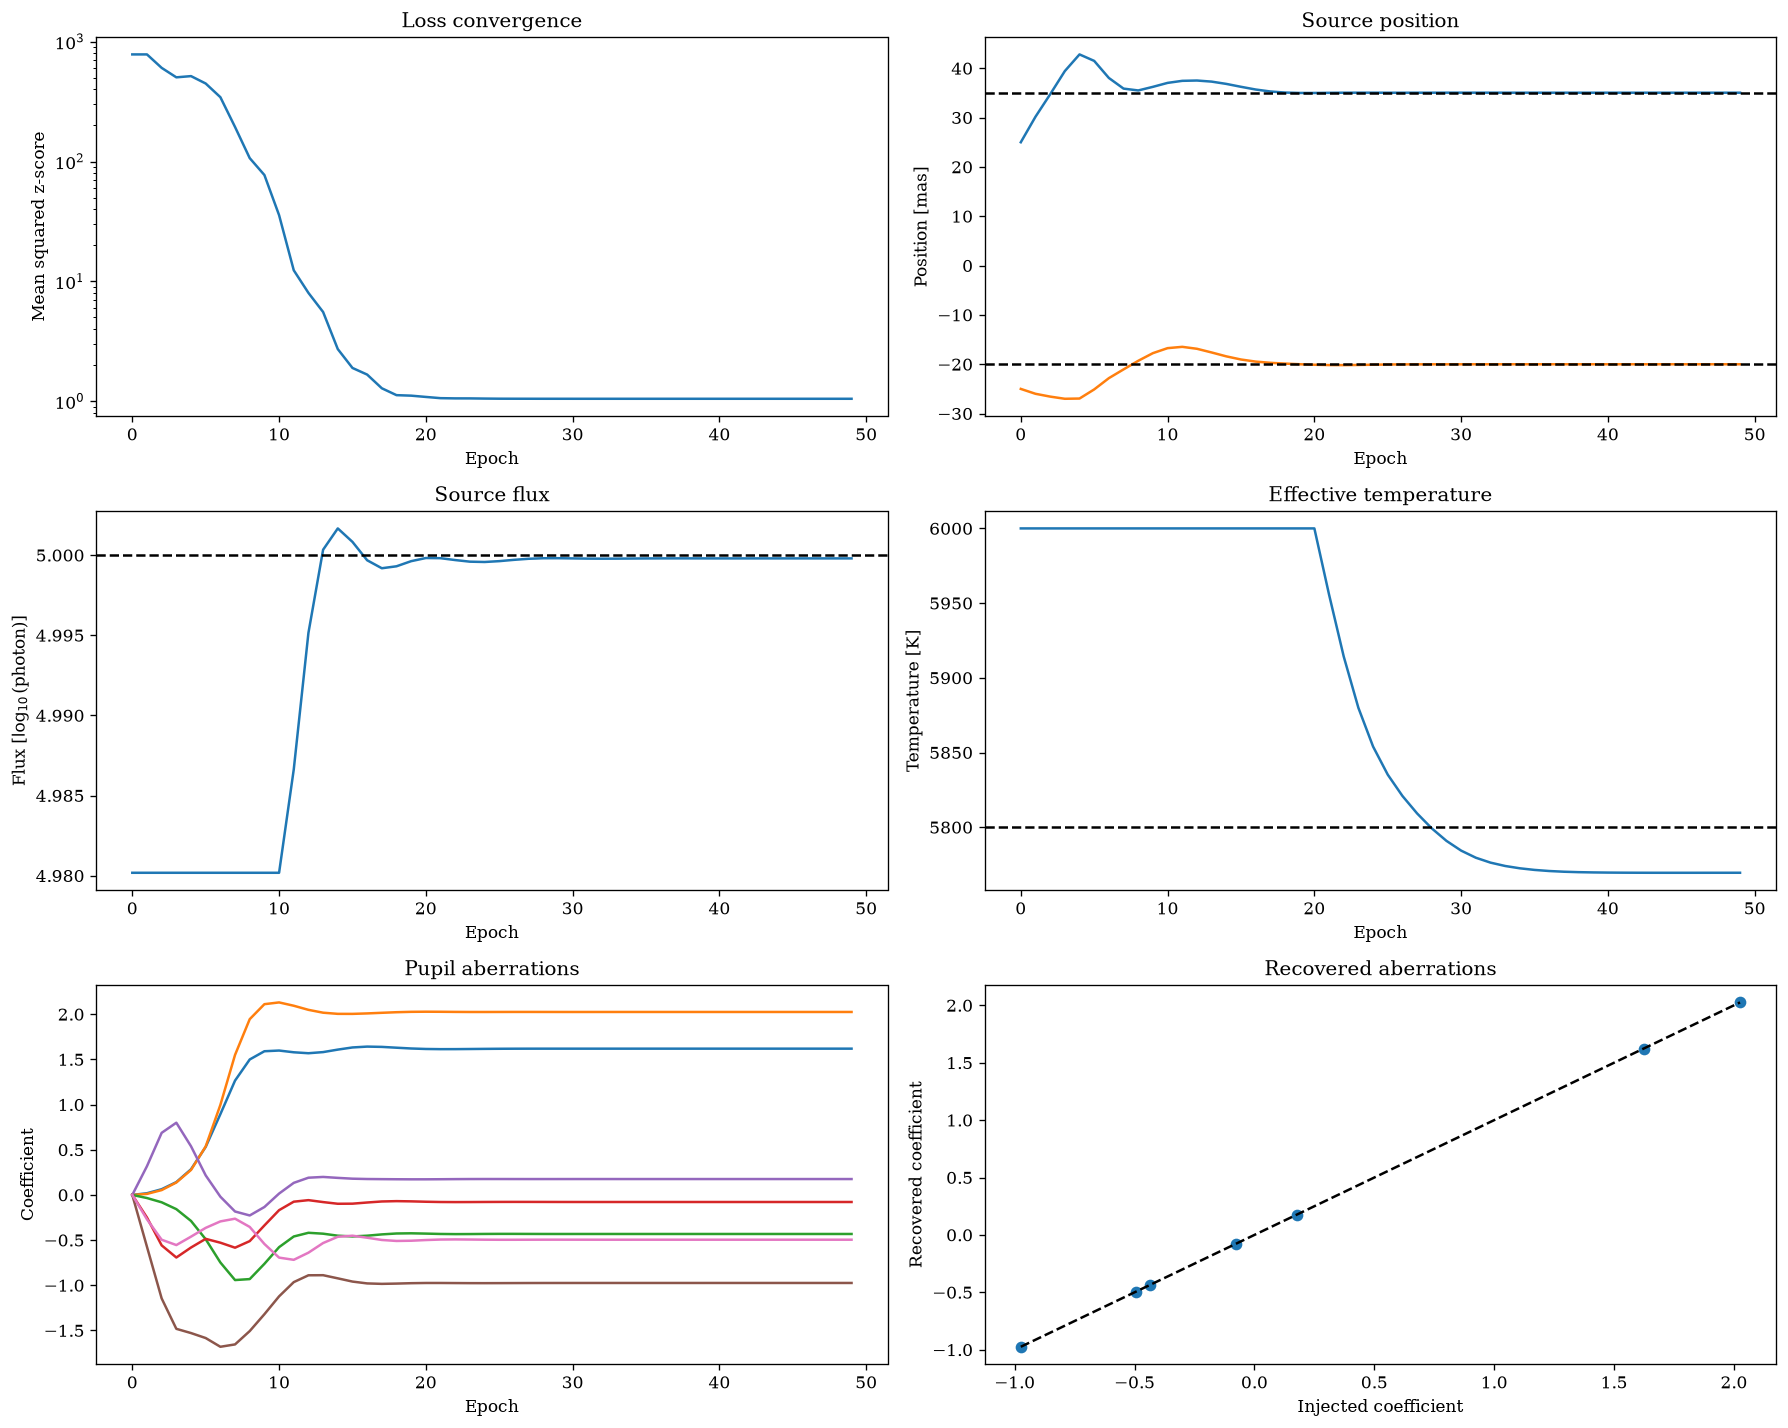

In [11]:
## COLLAPSE: Plotting code
# Convert the parameter history into arrays with a leading epoch axis
stack = lambda key: np.stack([values[key] for values in params_history])
history = {key: stack(key) for key in params}

# Plot convergence and recovery in the physical parameter units
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes[0, 0].plot(losses)
axes[0, 0].set(title="Loss convergence", xlabel="Epoch", ylabel="Mean squared z-score", yscale="log")

axes[0, 1].plot(history["position"])
axes[0, 1].axhline(truth["position"][0], color="k", ls="--")
axes[0, 1].axhline(truth["position"][1], color="k", ls="--")
axes[0, 1].set(title="Source position", xlabel="Epoch", ylabel="Position [mas]")

axes[1, 0].plot(history["flux"])
axes[1, 0].axhline(truth["flux"], color="k", ls="--")
axes[1, 0].set(title="Source flux", xlabel="Epoch", ylabel=r"Flux [$\log_{10}$(photon)]")

axes[1, 1].plot(history["temperature"])
axes[1, 1].axhline(truth["temperature"], color="k", ls="--")
axes[1, 1].set(title="Effective temperature", xlabel="Epoch", ylabel="Temperature [K]")

axes[2, 0].plot(history["pupil.coeffs"])
axes[2, 0].set(title="Pupil aberrations", xlabel="Epoch", ylabel="Coefficient")

limits = np.array([truth["pupil.coeffs"], params["pupil.coeffs"]])
axes[2, 1].scatter(truth["pupil.coeffs"], params["pupil.coeffs"])
axes[2, 1].plot([limits.min(), limits.max()], [limits.min(), limits.max()], "k--")
axes[2, 1].set(title="Recovered aberrations", xlabel="Injected coefficient", ylabel="Recovered coefficient")

fig.tight_layout()
plt.show()

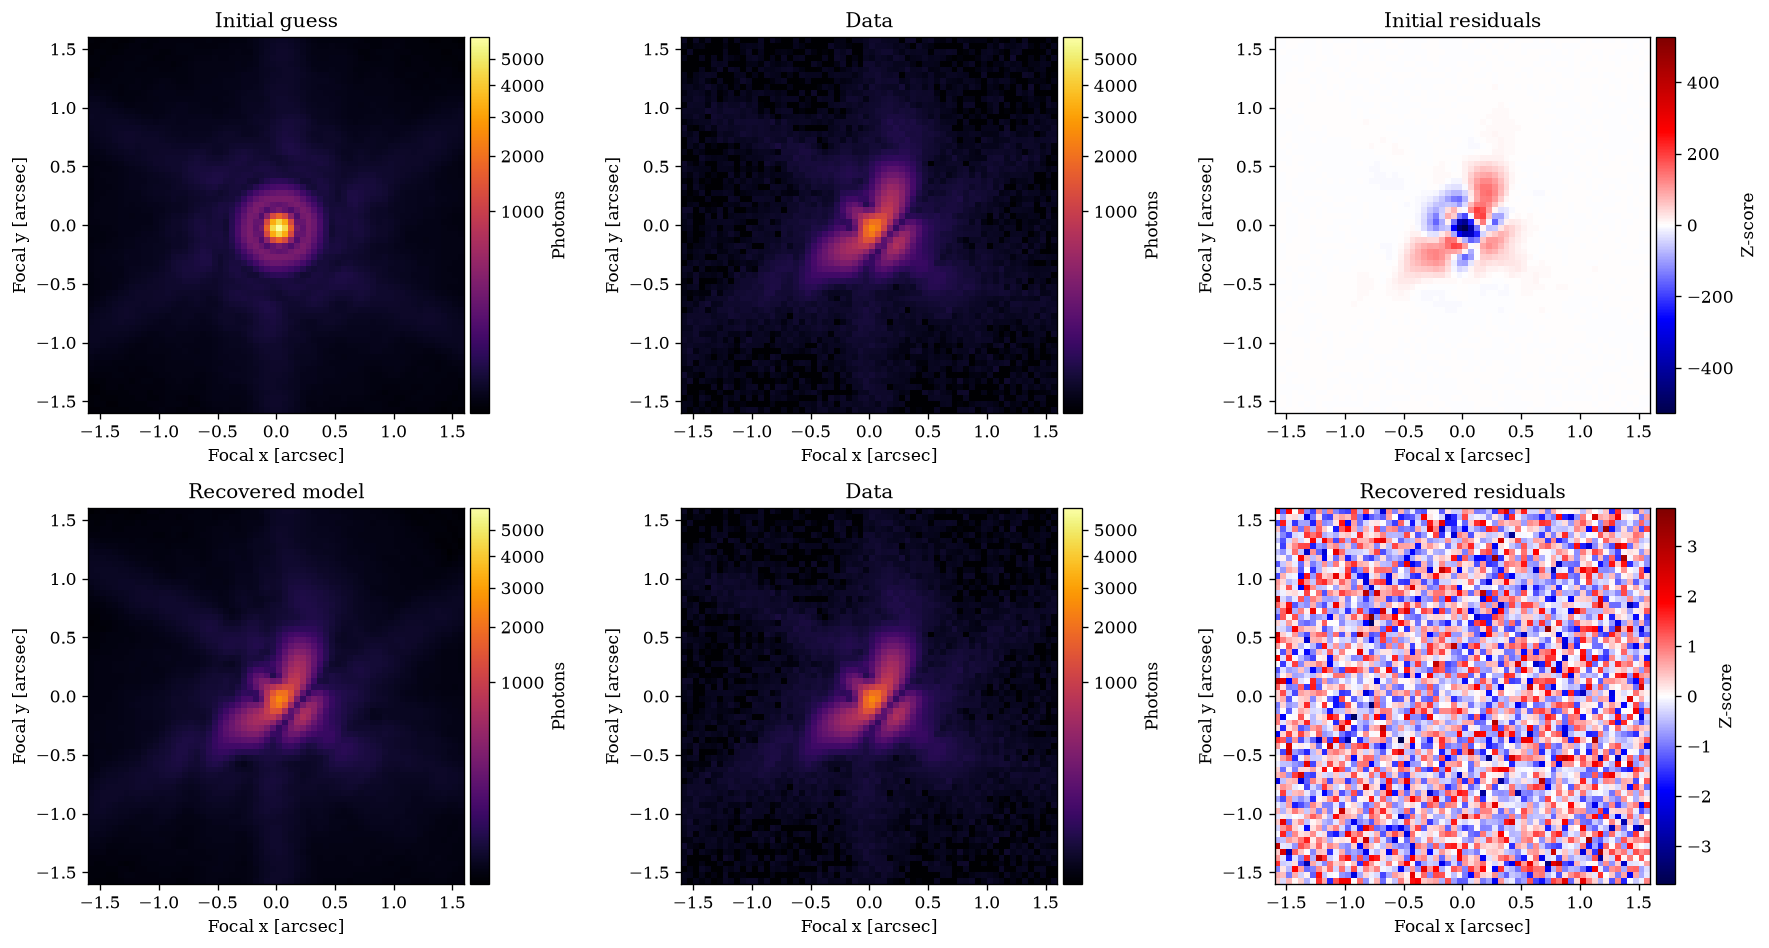

In [12]:
## COLLAPSE: Plotting code
# Evaluate the recovered image and both standardised residuals
fit_prediction = model_fn(params, optics, source)
start_z_score = exposure.z_score(start_prediction)
fit_z_score = exposure.z_score(fit_prediction)

# Use a shared photon scale to compare the data and both model images
images = np.stack([start_prediction.data, exposure.data, fit_prediction.data])
vmax = images.max()
image_norm = PowerNorm(0.35)

# Compare each prediction directly against the data and its residuals
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
im = axes[0, 0].imshow(start_prediction.data, cmaps["intensity"], extent=focal_extent, norm=image_norm)
axes[0, 0].set(title="Initial guess", xlabel="Focal x [arcsec]", ylabel="Focal y [arcsec]")
colorbar(im, "Photons")

im = axes[0, 1].imshow(exposure.data, cmaps["intensity"], extent=focal_extent, norm=image_norm)
axes[0, 1].set(title="Data", xlabel="Focal x [arcsec]", ylabel="Focal y [arcsec]")
colorbar(im, "Photons")

im = axes[0, 2].imshow(start_z_score, cmaps["residual"], extent=focal_extent, norm=CenteredNorm())
axes[0, 2].set(title="Initial residuals", xlabel="Focal x [arcsec]", ylabel="Focal y [arcsec]")
colorbar(im, "Z-score")

im = axes[1, 0].imshow(fit_prediction.data, cmaps["intensity"], extent=focal_extent, norm=image_norm)
axes[1, 0].set(title="Recovered model", xlabel="Focal x [arcsec]", ylabel="Focal y [arcsec]")
colorbar(im, "Photons")

im = axes[1, 1].imshow(exposure.data, cmaps["intensity"], extent=focal_extent, norm=image_norm)
axes[1, 1].set(title="Data", xlabel="Focal x [arcsec]", ylabel="Focal y [arcsec]")
colorbar(im, "Photons")

im = axes[1, 2].imshow(fit_z_score, cmaps["residual"], extent=focal_extent, norm=CenteredNorm())
axes[1, 2].set(title="Recovered residuals", xlabel="Focal x [arcsec]", ylabel="Focal y [arcsec]")
colorbar(im, "Z-score")

fig.tight_layout()
plt.show()

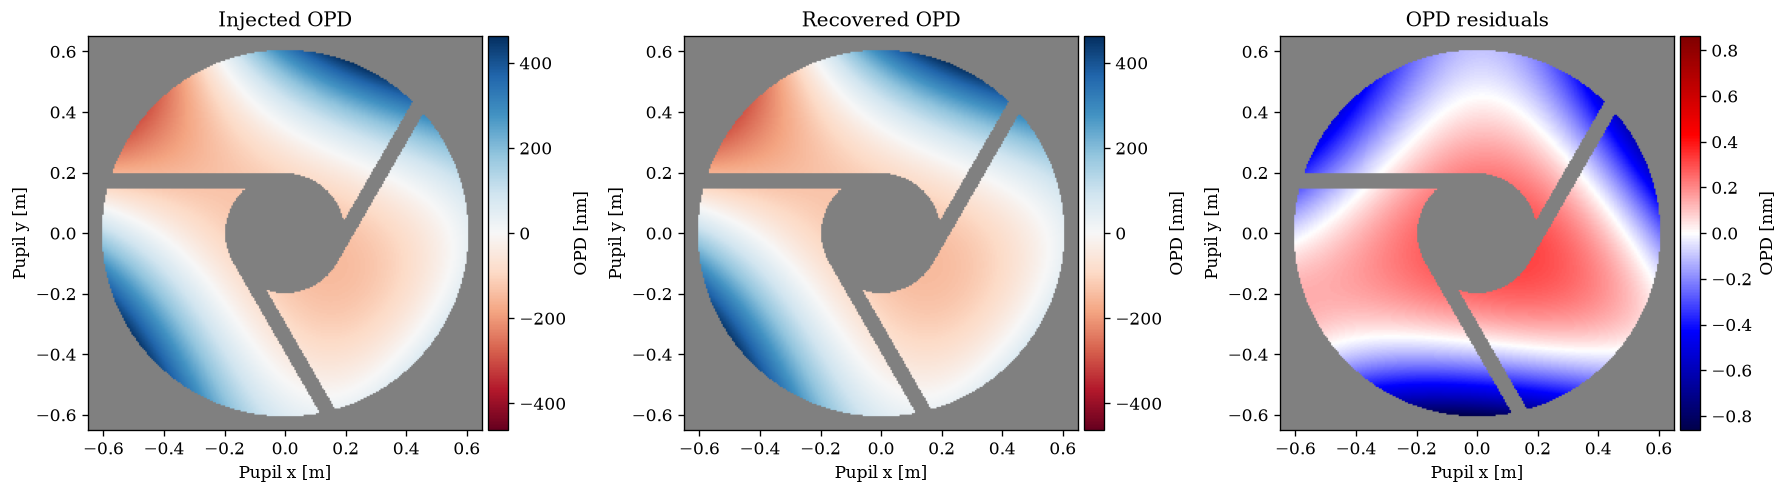

In [13]:
## COLLAPSE: Plotting code
# Evaluate the injected and recovered pupil-plane OPDs
fit_optics, _ = update(params, optics, source)
true_opd = 1e9 * optics.opd.evaluate()
fit_opd = 1e9 * fit_optics.opd.evaluate()
opd_residual = fit_opd - true_opd

# Mask values outside the physical aperture support
support = optics.transmission > 0.5
true_opd = np.where(support, true_opd, np.nan)
fit_opd = np.where(support, fit_opd, np.nan)
opd_residual = np.where(support, opd_residual, np.nan)

# Use one centred scale for the injected and recovered OPDs
limit = np.nanmax(np.abs(np.stack([true_opd, fit_opd])))
opd_norm = CenteredNorm(halfrange=limit)

# Compare the injected, recovered, and residual wavefront errors
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
im = axes[0].imshow(true_opd, cmaps["opd"], extent=pupil_extent, norm=opd_norm)
axes[0].set(title="Injected OPD", xlabel="Pupil x [m]", ylabel="Pupil y [m]")
colorbar(im, "OPD [nm]")

im = axes[1].imshow(fit_opd, cmaps["opd"], extent=pupil_extent, norm=opd_norm)
axes[1].set(title="Recovered OPD", xlabel="Pupil x [m]", ylabel="Pupil y [m]")
colorbar(im, "OPD [nm]")

im = axes[2].imshow(opd_residual, cmaps["residual"], extent=pupil_extent, norm=CenteredNorm())
axes[2].set(title="OPD residuals", xlabel="Pupil x [m]", ylabel="Pupil y [m]")
colorbar(im, "OPD [nm]")

fig.tight_layout()
plt.show()